# Imports necessários

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

# Configurações

In [2]:
# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Caminhos do projeto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cs-training.csv"

# Configurações do Pandas
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Configurações dos gráficos
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Ignorar warnings desnecessários
warnings.filterwarnings("ignore")

# Obtendo dados

In [8]:
df = pd.read_csv(DATA_PATH, sep=',')

rename_columns = {
    "Unnamed: 0": "id",
    "SeriousDlqin2yrs": "inadimplente",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacao_credito_rotativo",
    "age": "idade",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_atrasos_30_59_dias",
    "DebtRatio": "indice_endividamento",
    "MonthlyIncome": "renda_mensal",
    "NumberOfOpenCreditLinesAndLoans": "num_linhas_credito",
    "NumberOfTimes90DaysLate": "num_atrasos_acima_90_dias",
    "NumberRealEstateLoansOrLines": "num_emprestimos_imobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_atrasos_60_89_dias",
    "NumberOfDependents": "num_dependentes",
}

df = df.rename(columns=rename_columns)

In [9]:
target = "inadimplente"
variaveis = [c for c in df.columns if c not in ["id", target]]

# Entendo a base

In [5]:
print("=" * 70)
print("1. DISTRIBUIÇÃO DAS VARIÁVEIS")
print("=" * 70)
print(df[variaveis].describe().T)

1. DISTRIBUIÇÃO DAS VARIÁVEIS
                                 count    mean      std  min     25%     50%     75%        max
utilizacao_credito_rotativo  150000.00    6.05   249.76 0.00    0.03    0.15    0.56   50708.00
idade                        150000.00   52.30    14.77 0.00   41.00   52.00   63.00     109.00
num_atrasos_30_59_dias       150000.00    0.42     4.19 0.00    0.00    0.00    0.00      98.00
indice_endividamento         150000.00  353.01  2037.82 0.00    0.18    0.37    0.87  329664.00
renda_mensal                 120269.00 6670.22 14384.67 0.00 3400.00 5400.00 8249.00 3008750.00
num_linhas_credito           150000.00    8.45     5.15 0.00    5.00    8.00   11.00      58.00
num_atrasos_acima_90_dias    150000.00    0.27     4.17 0.00    0.00    0.00    0.00      98.00
num_emprestimos_imobiliarios 150000.00    1.02     1.13 0.00    0.00    1.00    2.00      54.00
num_atrasos_60_89_dias       150000.00    0.24     4.16 0.00    0.00    0.00    0.00      98.00
num_depend

### Primeiras Impressões:

* eu esperava que *utilizacao_credito_rotativo* seria um valor no intervalo [0, 1] por se tratar da razão uso/limite, mas claramente há valores extremos!!
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* *idade* possui um único valor que é erro, cuja idade é 0. podemos descartar sem preocupação

* *indice_endividamento* é a razão passivo/total, então quanto maior esse índice, mais arriscado um cliente (está endividado)

* *num_linhas_credito* e *num_emprestimos_imobiliarios* possuem valores muito altos, como 54 e 58. seriam flags?
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* os atrasos claramente possuem flags (96 e 98). quantos são esses registros? carregam informação do target?

* *num_dependentes* faz sentido ter valores altos como 20??


## utilizacao_credito_rotativo

In [7]:
sem_uso_credito = (df['utilizacao_credito_rotativo'] == 0)

print(f"\nsem_uso_credito:\n"
      f"{sem_uso_credito.sum()} registros "
      f"({sem_uso_credito.mean():.2%})")


print(f"\n{'=' * 70}")
print("Distribuição da variável alvo (inadimplente) para registros sem uso de crédito rotativo")
print(df[sem_uso_credito][target].value_counts(normalize=True))
# a proporção se manteve praticamente a mesma, indicando que o uso de crédito rotativo não é um fator determinante para inadimplência.


sem_uso_credito:
10878 registros (7.25%)

Distribuição da variável alvo (inadimplente) para registros sem uso de crédito rotativo
inadimplente
0   0.97
1   0.03
Name: proportion, dtype: float64


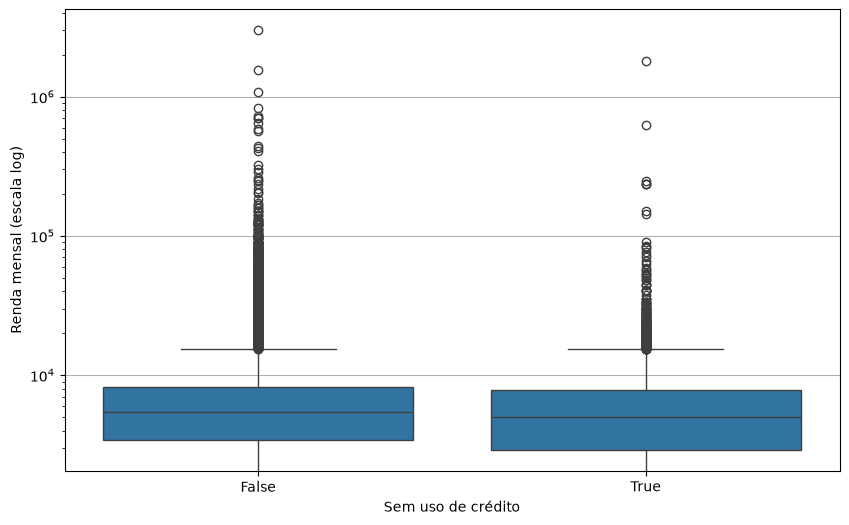

In [8]:
sns.boxplot(
    data=df,
    x=sem_uso_credito,
    y='renda_mensal'
)

plt.yscale('log')
plt.xlabel('Sem uso de crédito')
plt.ylabel('Renda mensal (escala log)')
plt.show()

In [9]:
anomalia_credito_rotativo = (df['utilizacao_credito_rotativo'] > 1)

print(f"\nutilizacao_credito_rotativo > 1: "
      f"{anomalia_credito_rotativo.sum()} registros "
      f"({anomalia_credito_rotativo.mean():.2%})")


utilizacao_credito_rotativo > 1: 3321 registros (2.21%)


In [10]:
print("\nDistribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:\n")
print("\n--- Geral ---")
print(df[target].value_counts(normalize=True))
print("\n--- Com anomalia ---")
print(df[anomalia_credito_rotativo][target].value_counts(normalize=True))
print("\n--- Sem anomalia ---")
print(df[~anomalia_credito_rotativo][target].value_counts(normalize=True))


Distribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:


--- Geral ---
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Com anomalia ---
inadimplente
0   0.63
1   0.37
Name: proportion, dtype: float64

--- Sem anomalia ---
inadimplente
0   0.94
1   0.06
Name: proportion, dtype: float64


In [11]:
df.groupby(target).agg({'utilizacao_credito_rotativo': 'median'})

,utilizacao_credito_rotativo
inadimplente,
0,0.13
1,0.84


#### anomalia do credito rotativo claramente carrega informação sobre o target!!!

In [16]:
medianas = df.groupby(anomalia_credito_rotativo)['renda_mensal'].median()

print(f"Sem anomalia: R$ {medianas[False]:,.2f}")
print(f"Com anomalia: R$ {medianas[True]:,.2f}")

Sem anomalia: R$ 5,416.00
Com anomalia: R$ 4,184.00


## indice_endividamento

In [18]:
df.groupby(target).agg({'indice_endividamento': 'median'})
# clientes inadimplentes possuem um índice de endividamento maior do que clientes adimplentes, o que é esperado.

,indice_endividamento
inadimplente,
0,0.36
1,0.43


In [34]:
endividados = (df['indice_endividamento'] > 1)

df[endividados].shape[0]
# cerca de 1/5 dos clientes possuem um índice de endividamento maior do que 1, o que indica que eles possuem mais dívidas do que renda mensal.
# será??

35137

In [42]:
print(df[endividados][target].value_counts(normalize=True))

df[endividados].groupby(target).agg({'renda_mensal': 'median'})

inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64


,renda_mensal
inadimplente,
0,1410.00
1,2900.00


In [44]:
print(df[~endividados][target].value_counts(normalize=True))

df[~endividados].groupby(target).agg({'renda_mensal': 'median'})

inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64


,renda_mensal
inadimplente,
0,5700.00
1,4626.50


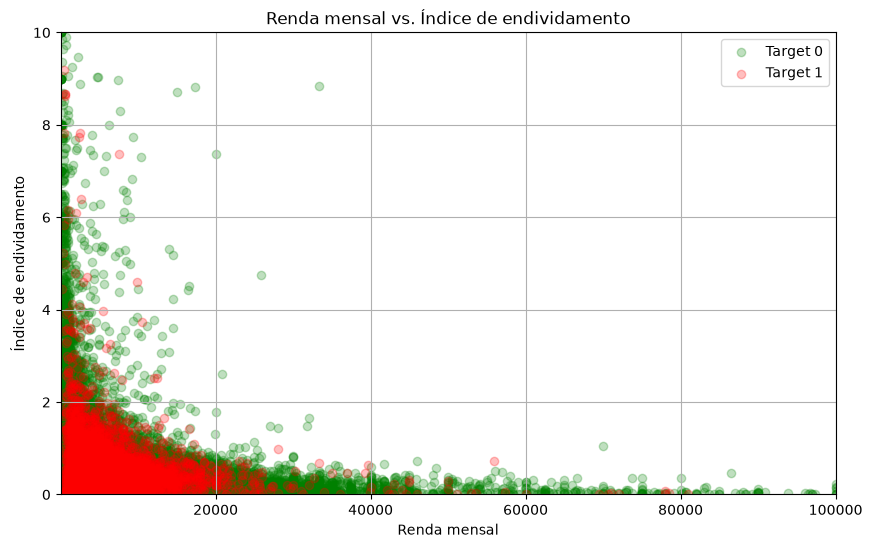

In [99]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df[target] == 0]['renda_mensal'],
    df[df[target] == 0]['indice_endividamento'],
    alpha=0.25,
    color='green',
    label='Target 0'
)

plt.scatter(
    df[df[target] == 1]['renda_mensal'],
    df[df[target] == 1]['indice_endividamento'],
    alpha=0.25,
    color='red',
    label='Target 1'
)

plt.xlim(1, 1e5)
plt.ylim(0, 10)

plt.xlabel('Renda mensal')
plt.ylabel('Índice de endividamento')
plt.title('Renda mensal vs. Índice de endividamento')
plt.legend()

plt.show()

### já conseguimos ter uma noção de como renda e endividamento se relacionam para identificar targets

In [54]:
df[['renda_mensal', 'indice_endividamento']].corr(method='spearman')

,renda_mensal,indice_endividamento
renda_mensal,1.00,-0.13
indice_endividamento,-0.13,1.00


## num_linhas_credito

In [19]:
df.groupby(target).agg({'num_linhas_credito': 'median'})

,num_linhas_credito
inadimplente,
0,8.00
1,7.00


### pessoas com menos linhas de crédito parecem ser mais arriscadas??

In [92]:
print('Proporção de inadimplentes em grupos com menos de 4 linhas de crédito:')
print(df[df['num_linhas_credito'] < 4][target].value_counts(normalize=True))
# cerca de 13% da base

print('\nProporção de inadimplentes em grupos com 4 ou mais linhas de crédito:')
print(df[df['num_linhas_credito'] >= 4][target].value_counts(normalize=True))

Proporção de inadimplentes em grupos com menos de 4 linhas de crédito:
inadimplente
0   0.89
1   0.11
Name: proportion, dtype: float64

Proporção de inadimplentes em grupos com 4 ou mais linhas de crédito:
inadimplente
0   0.94
1   0.06
Name: proportion, dtype: float64


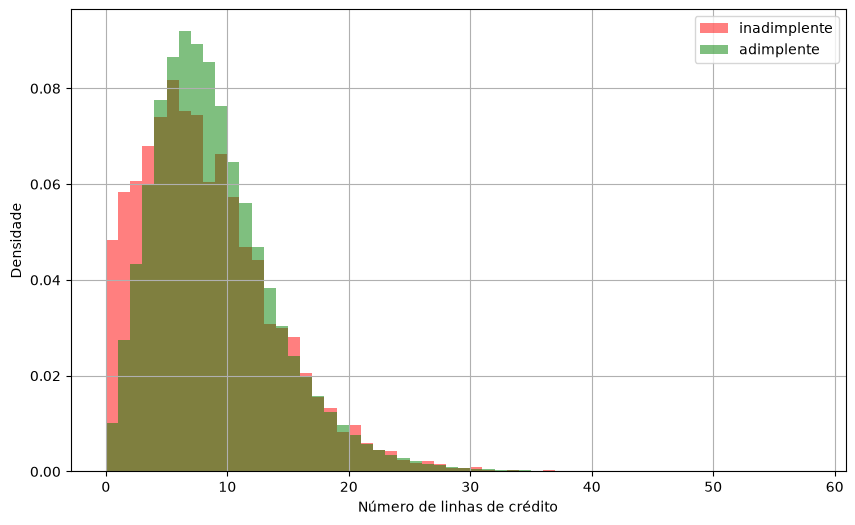

In [91]:
bins = np.arange(
    df['num_linhas_credito'].min(),
    df['num_linhas_credito'].max() + 1,
    1
)

df[df[target] == 1]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Número de linhas de crédito')
plt.ylabel('Densidade')
plt.show()

#### talvez cruzar essa info com outra feature possa revelar algo sobre o target

* a princípio, ter menos linhas de crédito tornam um cliente mais arriscado, mas talvez a renda possa influenciar
    * poucas linhas de crédito mas uma alta renda pode tornar o cliente menos arriscado
    * poucas linhas de crédito mas com alta renda pode tornar o cliente mais arriscado

    

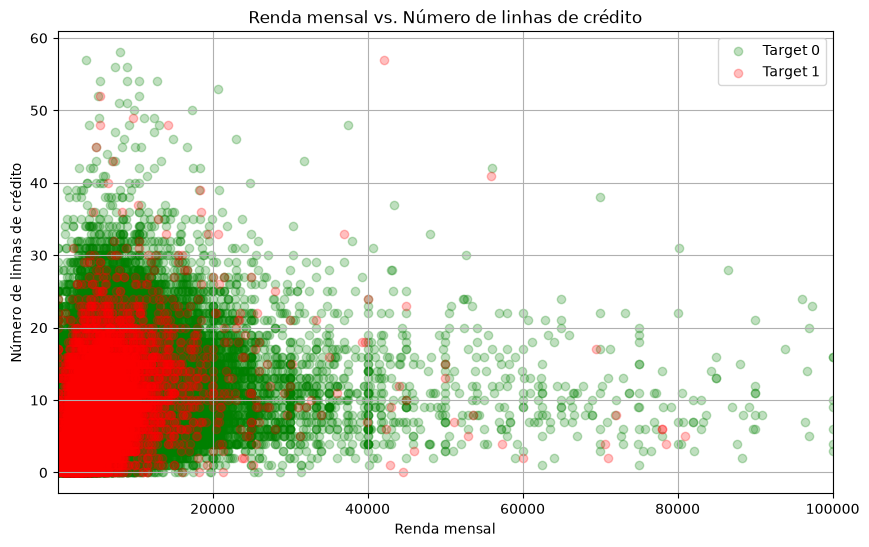

In [97]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df[target] == 0]['renda_mensal'],
    df[df[target] == 0]['num_linhas_credito'],
    alpha=0.25,
    color='green',
    label='Target 0'
)

plt.scatter(
    df[df[target] == 1]['renda_mensal'],
    df[df[target] == 1]['num_linhas_credito'],
    alpha=0.25,
    color='red',
    label='Target 1'
)

plt.xlim(1, 1e5)

plt.xlabel('Renda mensal')
plt.ylabel('Número de linhas de crédito')
plt.title('Renda mensal vs. Número de linhas de crédito')
plt.legend()

plt.show()

## num_emprestimos_imobiliarios

In [122]:
# maioria dos registros possuem até 2 emprestimos imobiliários
print(df['num_emprestimos_imobiliarios'].describe())
print('_'*70)
# qual a proporção de registros acima de 2 emprestimos imobiliários e qual a proporção de inadimplentes nesses registros
print('\nproporção de registros com mais de 2 empréstimos imobiliários:')
print(df[df['num_emprestimos_imobiliarios'] > 2].shape[0] / df.shape[0])
print('\nproporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] > 2][target].value_counts(normalize=True))
print('_'*70)

print('\nproporção de registros com 2 ou menos empréstimos imobiliários:')
print(df[df['num_emprestimos_imobiliarios'] <= 2].shape[0] / df.shape[0])
print('\n proporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] <= 2][target].value_counts(normalize=True))

print('_'*70)
print('\nproporção de registros com nenhuma empréstimo imobiliário:')
print(df[df['num_emprestimos_imobiliarios'] == 0].shape[0] / df.shape[0])
print('\nproporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] == 0][target].value_counts(normalize=True)) 

count   150000.00
mean         1.02
std          1.13
min          0.00
25%          0.00
50%          1.00
75%          2.00
max         54.00
Name: num_emprestimos_imobiliarios, dtype: float64
______________________________________________________________________

proporção de registros com mais de 2 empréstimos imobiliários:
0.06634666666666666

proporção de inadimplentes nesses registros:
inadimplente
0   0.92
1   0.08
Name: proportion, dtype: float64
______________________________________________________________________

proporção de registros com 2 ou menos empréstimos imobiliários:
0.9336533333333333

 proporção de inadimplentes nesses registros:
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64
______________________________________________________________________

proporção de registros com nenhuma empréstimo imobiliário:
0.3745866666666667

proporção de inadimplentes nesses registros:
inadimplente
0   0.92
1   0.08
Name: proportion, dtype: float64


## atrasos

In [135]:
colunas_atraso = [
    "num_atrasos_30_59_dias",
    "num_atrasos_60_89_dias",
    "num_atrasos_acima_90_dias",
]
print("Valores mais frequentes nas colunas de atraso (checar códigos especiais):")
for col in colunas_atraso:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index(ascending=False).head(5))

Valores mais frequentes nas colunas de atraso (checar códigos especiais):

--- num_atrasos_30_59_dias ---
num_atrasos_30_59_dias
98    264
96      5
13      1
12      2
11      1
Name: count, dtype: int64

--- num_atrasos_60_89_dias ---
num_atrasos_60_89_dias
98    264
96      5
11      1
9       1
8       2
Name: count, dtype: int64

--- num_atrasos_acima_90_dias ---
num_atrasos_acima_90_dias
98    264
96      5
17      1
15      2
14      2
Name: count, dtype: int64


### claramente 98 e 96 são flags, mas flags de quê?? são coincidentes?

In [129]:
print('flag de atraso (30-59 dias) = 96:')
print(df[df['num_atrasos_30_59_dias'] == 96][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T)

print('\n\nflag de atraso (30-59 dias) = 98:')
print(df[df['num_atrasos_30_59_dias'] == 98][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T)

flag de atraso (30-59 dias) = 96:
                           count  mean  std   min   25%   50%   75%   max
num_atrasos_30_59_dias      5.00 96.00 0.00 96.00 96.00 96.00 96.00 96.00
num_atrasos_60_89_dias      5.00 96.00 0.00 96.00 96.00 96.00 96.00 96.00
num_atrasos_acima_90_dias   5.00 96.00 0.00 96.00 96.00 96.00 96.00 96.00


flag de atraso (30-59 dias) = 98:
                           count  mean  std   min   25%   50%   75%   max
num_atrasos_30_59_dias    264.00 98.00 0.00 98.00 98.00 98.00 98.00 98.00
num_atrasos_60_89_dias    264.00 98.00 0.00 98.00 98.00 98.00 98.00 98.00
num_atrasos_acima_90_dias 264.00 98.00 0.00 98.00 98.00 98.00 98.00 98.00


### sim, são coincidentes --> menos trabalho :)

In [133]:
atrasos_flag = df['num_atrasos_30_59_dias'].isin([96, 98]) # (como são coincidentes, tanto faz qual coluna usar)

print(df[atrasos_flag][target].value_counts(normalize=True))
print('\nquantidade de registros:', df[atrasos_flag].shape[0])


# carrega bastante informação sobre o target!!! cerca de metade desses registros são inadimplentes, enquanto na base geral a proporção é de apenas 7,5%

inadimplente
1   0.55
0   0.45
Name: proportion, dtype: float64

quantidade de registros: 269


In [ ]:
df[~atrasos_flag][target].value_counts(normalize=True) # sem a flag, a proporção de inadimplentes é igual a da base

inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

In [140]:
df[colunas_atraso + [target]].corr(method='spearman')

,num_atrasos_30_59_dias,num_atrasos_60_89_dias,num_atrasos_acima_90_dias,inadimplente
num_atrasos_30_59_dias,1.00,0.28,0.25,0.26
num_atrasos_60_89_dias,0.28,1.00,0.32,0.28
num_atrasos_acima_90_dias,0.25,0.32,1.00,0.34
inadimplente,0.26,0.28,0.34,1.00


In [154]:
resultados = []

for col in colunas_atraso:

    aux = (
        df.assign(
            teve_atraso=df[col] > 0
        )
        .groupby('teve_atraso')[target]
        .agg(
            proporcao_inadimplentes='mean',
            registros='count'
        )
    )

    aux['proporcao_inadimplentes'] *= 100
    aux['variavel'] = col

    resultados.append(aux.reset_index())

analise = pd.concat(resultados, ignore_index=True)

analise

,teve_atraso,proporcao_inadimplentes,registros,variavel
0,False,4.00,126018,num_atrasos_30_59_dias
1,True,20.79,23982,num_atrasos_30_59_dias
2,False,5.10,142396,num_atrasos_60_89_dias
3,True,36.43,7604,num_atrasos_60_89_dias
4,False,4.63,141662,num_atrasos_acima_90_dias
5,True,41.64,8338,num_atrasos_acima_90_dias


### forte relação entre ter atraso e ser inadimplente

## num_dependentes

In [ ]:
df['num_dependentes'].value_counts()
# a partir de 5 dependentes, quase não observamos registros. se dividirmos a base em dois grupos (até 4 dependentes e mais de 4 dependentes), como se comporta a taxa de inadimplência?

num_dependentes
0.00     86902
1.00     26316
2.00     19522
3.00      9483
4.00      2862
5.00       746
6.00       158
7.00        51
8.00        24
10.00        5
9.00         5
20.00        1
13.00        1
Name: count, dtype: int64

In [157]:
ate_5_dependentes = (df['num_dependentes'] <= 4)
mais_5_dependentes = (df['num_dependentes'] > 4)

print("\nDistribuição do target (inadimplente) para registros com até 4 dependentes e mais de 4 dependentes:\n")
print("\n--- Até 4 dependentes ---", df[ate_5_dependentes].shape[0], 'registros')
print(df[ate_5_dependentes][target].value_counts(normalize=True))
print("\n--- Mais de 4 dependentes ---", df[mais_5_dependentes].shape[0], 'registros')
print(df[mais_5_dependentes][target].value_counts(normalize=True))



Distribuição do target (inadimplente) para registros com até 4 dependentes e mais de 4 dependentes:


--- Até 4 dependentes --- 145085 registros
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Mais de 4 dependentes --- 991 registros
inadimplente
0   0.90
1   0.10
Name: proportion, dtype: float64


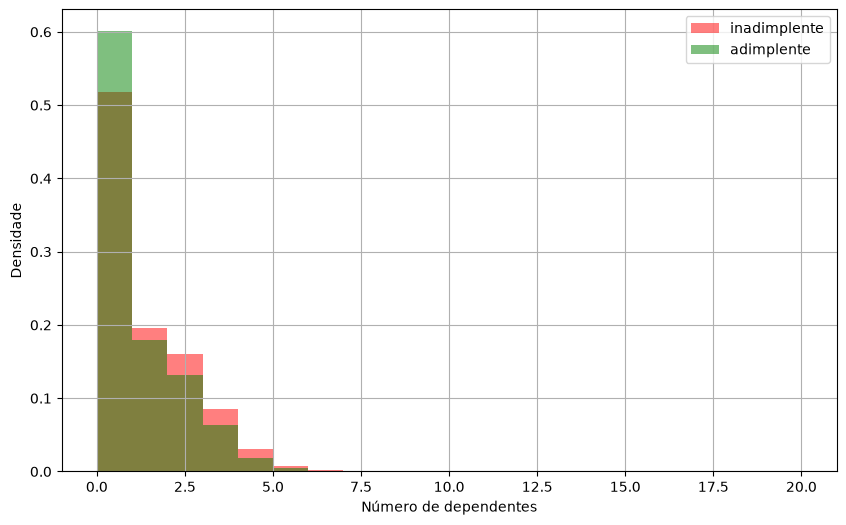

In [161]:
bins = np.arange(
    df['num_dependentes'].min(),
    df['num_dependentes'].max() + 1,
    1
)

df[df[target] == 1]['num_dependentes'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['num_dependentes'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Número de dependentes')
plt.ylabel('Densidade')
plt.show()

### essa é uma das features que possui Nans... será que carregam informação?

In [ ]:
dependentes_nans = df['num_dependentes'].isna()

print("Distribuição do target para registros com valores ausentes em 'num_dependentes':")
print('total de', dependentes_nans.sum(), 'registros\n')
print(df[dependentes_nans][target].value_counts(normalize=True))

# proporçao de inadimplentes para registros com valores ausentes é próximo à proporçao da base geral, indicando que a ausência de informação sobre o número de dependentes não está relacionada à inadimplência.


Distribuição do target para registros com valores ausentes em 'num_dependentes':
total de 3924 registros

inadimplente
0   0.95
1   0.05
Name: proportion, dtype: float64


## renda_mensal

In [ ]:
df['renda_mensal'].describe()

# é uma feature muito variada. além disso, pode ser que valores puros nao informem nada, afinal, um cliente alta renda nem sempre é um cliente de baixo risco. talvez seja interessante criar uma nova feature a partir da renda (normalizar a renda em relação ao número de dependentes, por exemplo)

count    120269.00
mean       6670.22
std       14384.67
min           0.00
25%        3400.00
50%        5400.00
75%        8249.00
max     3008750.00
Name: renda_mensal, dtype: float64

In [32]:
df.groupby(target).agg({'renda_mensal': 'median'})
# inadimplentes tem renda mediana de 4.500, enquanto adimplentes tem renda mediana de 5.500. portanto, não há indício de que a renda esteja relacionada à inadimplência.

,renda_mensal
inadimplente,
0,5466.00
1,4500.00


In [167]:
bins = [0, 1000, 2000, 3000, 4000, 5000, 7000, 10000, np.inf]

df['faixa_renda'] = pd.cut(
    df['renda_mensal'],
    bins=bins
)

analise = (
    df.groupby('faixa_renda', observed=True)[target]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

analise

inadimplente,0,1
faixa_renda,,
"(0.0, 1000.0]",0.94,0.06
"(1000.0, 2000.0]",0.89,0.11
"(2000.0, 3000.0]",0.90,0.10
"(3000.0, 4000.0]",0.91,0.09
"(4000.0, 5000.0]",0.92,0.08
"(5000.0, 7000.0]",0.93,0.07
"(7000.0, 10000.0]",0.95,0.05
"(10000.0, inf]",0.96,0.04


In [171]:
df['decil_renda'] = pd.qcut(
    df['renda_mensal'],
    q=10,
    duplicates='drop'
)

analise = (
    df.groupby('decil_renda', observed=True)[target]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

analise[1] * 100

decil_renda
(-0.001, 2005.0]       8.44
(2005.0, 3000.0]       9.67
(3000.0, 3800.0]       9.11
(3800.0, 4544.2]       8.09
(4544.2, 5400.0]       7.33
(5400.0, 6300.0]       6.68
(6300.0, 7500.0]       5.93
(7500.0, 9083.0]       5.11
(9083.0, 11666.0]      4.52
(11666.0, 3008750.0]   4.49
Name: 1, dtype: float64

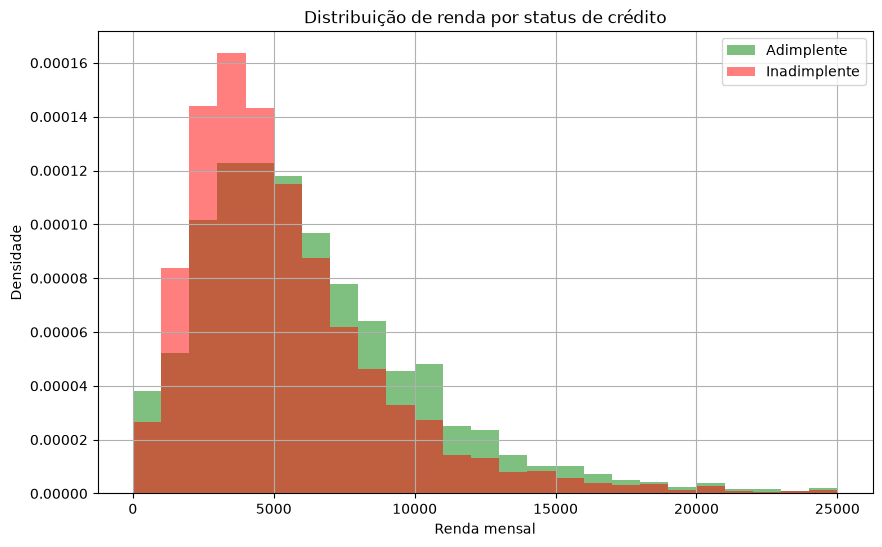

In [172]:
bins = np.arange(
    0,
    df['renda_mensal'].quantile(0.99) + 1000,
    1000
)

plt.figure(figsize=(10, 6))

df[df[target] == 0]['renda_mensal'].hist(
    bins=bins,
    density=True,
    alpha=0.5,
    color='green',
    label='Adimplente'
)

df[df[target] == 1]['renda_mensal'].hist(
    bins=bins,
    density=True,
    alpha=0.5,
    color='red',
    label='Inadimplente'
)

plt.xlabel('Renda mensal')
plt.ylabel('Densidade')
plt.title('Distribuição de renda por status de crédito')
plt.legend()

plt.show()

In [178]:
from scipy.stats import ks_2samp

renda_0 = df.loc[df[target] == 0, 'renda_mensal'].dropna()
renda_1 = df.loc[df[target] == 1, 'renda_mensal'].dropna()

resultado = ks_2samp(renda_0, renda_1)

print(f"KS: {resultado.statistic:.4f}")
print(f"p-value: {resultado.pvalue:.4f}")

KS: 0.1256
p-value: 0.0000


### renda_mensal é uma das features que possui Nans... vamos verificar se há informação sobre o target

In [180]:
renda_nan = df['renda_mensal'].isna()

print('quantidade de registros com renda ausente:', renda_nan.sum())
df.groupby(df['renda_mensal'].isna())[target].value_counts(normalize=True)

# a proporção de inadimplentes para registros com valores ausentes em 'renda_mensal' é próxima à proporção da base geral.
# ausência dessa informação não parece estar relacionada à inadimplência.
# mas novamente, é 1%... talvez seja significativo sim, como avaliar??

quantidade de registros com renda ausente: 29731


renda_mensal  inadimplente
False         0              0.93
              1              0.07
True          0              0.94
              1              0.06
Name: proportion, dtype: float64

## Avaliando porcentagem de targets por quantil das variáveis

In [40]:
print("\n" + "=" * 70)
print("3. TAXA DE INADIMPLÊNCIA POR FAIXA (QUARTIL) DE CADA VARIÁVEL")
print("=" * 70)

quantil = 4

for col in variaveis:
    print(f"\n--- {col} ---")
    try:
        faixas = pd.qcut(df[col], q=quantil, duplicates="drop")
        tabela = df.groupby(faixas, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(tabela)
    except ValueError as e:
        tabela = df.groupby(col, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(f"(não foi possível dividir em quartis: {e})")
        print("Agrupando por valor único da coluna em vez disso:")
        print(tabela)


3. TAXA DE INADIMPLÊNCIA POR FAIXA (QUARTIL) DE CADA VARIÁVEL

--- utilizacao_credito_rotativo ---
                             taxa_inadimplencia  qtd_clientes
utilizacao_credito_rotativo                                  
(-0.001, 0.0299]                           0.02         37500
(0.0299, 0.154]                            0.02         37500
(0.154, 0.559]                             0.05         37500
(0.559, 50708.0]                           0.18         37500

--- idade ---
                taxa_inadimplencia  qtd_clientes
idade                                           
(-0.001, 41.0]                0.10         38219
(41.0, 52.0]                  0.08         39151
(52.0, 63.0]                  0.05         38379
(63.0, 109.0]                 0.03         34251

--- num_atrasos_30_59_dias ---
                        taxa_inadimplencia  qtd_clientes
num_atrasos_30_59_dias                                  
(-0.001, 98.0]                        0.07        150000

--- indice_endi

In [10]:
"""
Etapa 2 da EDA - Give Me Some Credit
-------------------------------------
1. Tratamento das flags 96/98 nas colunas de atraso
2. Teste estatístico formal para decidir se o missing é informativo
3. Heatmap bivariado (taxa de inadimplência por combinação de faixas)

Assume que `df` já existe, com as colunas renomeadas em português e
a coluna target `inadimplente`.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest

target = "inadimplente"


# =================================================================
# 1. TRATAMENTO DAS FLAGS 96/98
# =================================================================
# Estratégia escolhida: criar uma flag binária que preserva a
# informação de que esses clientes são estruturalmente diferentes,
# e substituir o valor 96/98 nas colunas originais por algo que não
# distorça o restante da distribuição (aqui, o máximo "real" da
# coluna, ou seja, o maior valor abaixo de 96).

colunas_atraso = [
    "num_atrasos_30_59_dias",
    "num_atrasos_60_89_dias",
    "num_atrasos_acima_90_dias",
]

# 1.1 Cria a flag: 1 se o cliente tem valor 96 OU 98 em qualquer uma
# das 3 colunas de atraso, 0 caso contrário.
mask_flag = df[colunas_atraso].isin([96, 98]).any(axis=1)
df["flag_atraso_especial"] = mask_flag.astype(int)

print(f"Total de clientes com flag_atraso_especial = 1: {mask_flag.sum()} "
      f"({mask_flag.mean():.2%})")

# 1.2 Confere se essa flag sozinha já carrega sinal de risco
# (comparação simples de taxa de inadimplência entre os dois grupos).
taxa_com_flag = df.loc[mask_flag, target].mean()
taxa_sem_flag = df.loc[~mask_flag, target].mean()
print(f"Taxa de inadimplência COM flag: {taxa_com_flag:.2%}")
print(f"Taxa de inadimplência SEM flag: {taxa_sem_flag:.2%}")

# 1.3 Substitui 96/98 pelo maior valor "real" de cada coluna
# (ou seja, o máximo desconsiderando os próprios códigos especiais).
# Isso evita que XGBoost trate 96/98 como uma contagem literal de
# atrasos, o que distorceria completamente os splits da árvore.
for col in colunas_atraso:
    valor_max_real = df.loc[~df[col].isin([96, 98]), col].max()
    df[col] = df[col].replace({96: valor_max_real, 98: valor_max_real})
    print(f"{col}: valores 96/98 substituídos por {valor_max_real}")


# =================================================================
# 2. TESTE ESTATÍSTICO PARA O MISSING (renda_mensal e num_dependentes)
# =================================================================
# Pergunta: a diferença de taxa de inadimplência entre "tem o dado" e
# "não tem o dado" é estatisticamente significativa, ou pode ser
# só ruído amostral?
#
# Usamos um teste z de duas proporções (proportions_ztest), que
# compara duas taxas (proporções) considerando o tamanho de cada
# grupo. H0 (hipótese nula): as duas proporções são iguais.
# Se o p-valor for menor que 0.05, rejeitamos H0 e concluímos que a
# diferença é estatisticamente significativa.

colunas_com_missing = ["renda_mensal", "num_dependentes"]

print("\n" + "=" * 70)
print("TESTE DE PROPORÇÃO: taxa de inadimplência COM vs SEM missing")
print("=" * 70)

for col in colunas_com_missing:
    tem_dado = df[col].notnull()
    sem_dado = df[col].isnull()

    # "sucessos" aqui = quantidade de inadimplentes em cada grupo
    sucessos = [
        df.loc[tem_dado, target].sum(),
        df.loc[sem_dado, target].sum(),
    ]
    # tamanho de cada grupo
    n_obs = [tem_dado.sum(), sem_dado.sum()]

    stat, p_valor = proportions_ztest(count=sucessos, nobs=n_obs)

    print(f"\n--- {col} ---")
    print(f"Taxa COM dado: {sucessos[0] / n_obs[0]:.4%}  (n={n_obs[0]})")
    print(f"Taxa SEM dado: {sucessos[1] / n_obs[1]:.4%}  (n={n_obs[1]})")
    print(f"Estatística z: {stat:.4f}")
    print(f"P-valor: {p_valor:.6f}")
    if p_valor < 0.05:
        print("=> Diferença ESTATISTICAMENTE SIGNIFICATIVA (rejeita H0).")
        print("   O missing carrega algum sinal; considere manter como")
        print("   categoria própria em vez de só imputar.")
    else:
        print("=> Diferença NÃO significativa (não rejeita H0).")
        print("   Pode tratar o missing como não informativo (MCAR) e")
        print("   seguir com imputação simples (ex: mediana).")


# =================================================================
# 3. HEATMAP BIVARIADO
# =================================================================
# Ideia: discretizar duas variáveis em faixas (quartis) e calcular a
# taxa de inadimplência para cada combinação de faixas. Isso é mais
# informativo que um scatter plot cru, porque agrega o ruído visual
# em células com significado direto (taxa de risco).
#
# Vamos comparar as duas variáveis mais fortes que você já identificou:
# utilizacao_credito_rotativo e num_atrasos_30_59_dias (agora já sem
# os códigos especiais, tratados na etapa 1).

def heatmap_bivariado(df, col_x, col_y, target, bins=4):
    """
    Gera um heatmap de taxa de inadimplência cruzando duas variáveis
    discretizadas em faixas (quartis por padrão).
    """
    # pd.qcut cria faixas com quantidade parecida de observações.
    # duplicates="drop" evita erro quando há muitos valores repetidos.
    faixa_x = pd.qcut(df[col_x], q=bins, duplicates="drop")
    faixa_y = pd.qcut(df[col_y], q=bins, duplicates="drop")

    # Tabela pivot: linhas = faixas de Y, colunas = faixas de X,
    # valores = taxa média da target (proporção de inadimplentes).
    tabela = df.groupby([faixa_y, faixa_x], observed=True)[target].mean().unstack()

    plt.figure(figsize=(8, 6))
    sns.heatmap(tabela, annot=True, fmt=".2%", cmap="Reds")
    plt.title(f"Taxa de inadimplência: {col_y} x {col_x}")
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.tight_layout()
    nome_arquivo = f"heatmap_{col_x}_x_{col_y}.png"
    plt.savefig(nome_arquivo)
    plt.close()
    print(f"\n[salvo] {nome_arquivo}")


heatmap_bivariado(df, "utilizacao_credito_rotativo", "num_atrasos_30_59_dias", target)

# Sugestão de outro par interessante: idade x indice_endividamento
# (descomente para gerar)
# heatmap_bivariado(df, "indice_endividamento", "idade")

print("\nFim da etapa 2. Revise os heatmaps gerados e os p-valores")
print("antes de decidir a estratégia final de imputação e seguir")
print("para o binning com optbinning.")

Total de clientes com flag_atraso_especial = 1: 269 (0.18%)
Taxa de inadimplência COM flag: 54.65%
Taxa de inadimplência SEM flag: 6.60%
num_atrasos_30_59_dias: valores 96/98 substituídos por 13
num_atrasos_60_89_dias: valores 96/98 substituídos por 11
num_atrasos_acima_90_dias: valores 96/98 substituídos por 17

TESTE DE PROPORÇÃO: taxa de inadimplência COM vs SEM missing

--- renda_mensal ---
Taxa COM dado: 6.9486%  (n=120269)
Taxa SEM dado: 5.6137%  (n=29731)
Estatística z: 8.2527
P-valor: 0.000000
=> Diferença ESTATISTICAMENTE SIGNIFICATIVA (rejeita H0).
   O missing carrega algum sinal; considere manter como
   categoria própria em vez de só imputar.

--- num_dependentes ---
Taxa COM dado: 6.7410%  (n=146076)
Taxa SEM dado: 4.5617%  (n=3924)
Estatística z: 5.3943
P-valor: 0.000000
=> Diferença ESTATISTICAMENTE SIGNIFICATIVA (rejeita H0).
   O missing carrega algum sinal; considere manter como
   categoria própria em vez de só imputar.

[salvo] heatmap_utilizacao_credito_rotativo_x